# **Motorbike Ambulance Calls**
>Motorbike accidents and corresponded ambulance calls are highly depended on environmental and seasonal settings, like weather conditions, precipitation, day of week, season, hour of the day, etc. The data was aggregated over the course of two years, on hourly basis, and then extracted and extended with the corresponding weather and seasonal information.


## **Associated tasks**

---


**Regression**

Prediction of the hourly ambulance calls count based on the environmental and seasonal settings. Prediction model should provide monotonic in the terms of some features, if it is proved by data.

**Event and Anomaly Detection**

Define the  ambulance calls patterns with respect of special events and define the cases that might be considered as abnormal behavior.  

**Deliverables**

Full Texts Report that contains detail description of Data Analysis, Data Modelling and Patterns/Anomaly detection processes with conclusions and their explanations.
What is important here:
* See the **way you’re thinking** – what actions you’re implementing and why
* How **you code** and wrangle the data
* **Storytelling** capabilities – so we’re looking for the full-text structured report separately from the code/notebook
* **Suggestions** on the further  analytics/approaches which could be applied

## **Dataset characteristics:**

---



motorbike_ambulance_calls.csv has the following fields:

              - index: record index
              - date : date
              - season : season (1:springer, 2:summer, 3:fall, 4:winter)
              - yr : year (0: 2011, 1:2012)
              - mnth : month ( 1 to 12)
              - hr : hour (0 to 23)
              - holiday : whether day is holiday or not
              - weekday : day of the week
              - workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
              -  weathersit :
                      - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
                      - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
                      - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
                      - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
              - temp : Normalized temperature in Celsius. The values are divided to 41 (max)
              - atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
              - hum: Normalized humidity. The values are divided to 100 (max)
              - windspeed: Normalized wind speed. The values are divided to 67 (max)
              - cnt: count of total ambulance calls


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pylab import rcParams
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
from scipy import stats

np.random.seed(42)
plt.style.use('classic')
rcParams['figure.figsize'] = 12, 8

In [17]:
df = pd.read_csv('motorbike_ambulance_calls.csv')

df['date'] = pd.to_datetime(df['date'], format='%m/%d/%y')
df['month_name'] = df['date'].dt.month_name()
df['is_weekend'] = df['date'].dt.weekday.isin([5, 6]).astype(int)
df['is_rush_hour'] = df['hr'].isin([7, 8, 9, 16, 17, 18]).astype(int)
df['hour_band'] = pd.cut(
    df['hr'],
    bins=[-1, 6, 12, 18, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

print(df.head())

   index       date  season  yr  mnth  hr  holiday  weekday  workingday  \
0      1 2011-01-01  spring   0     1   0        0        6           0   
1      2 2011-01-01  spring   0     1   1        0        6           0   
2      3 2011-01-01  spring   0     1   2        0        6           0   
3      4 2011-01-01  spring   0     1   3        0        6           0   
4      5 2011-01-01  spring   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  cnt month_name  is_weekend  \
0           1  0.24  0.2879  0.81        0.0   16    January           1   
1           1  0.22  0.2727  0.80        0.0   40    January           1   
2           1  0.22  0.2727  0.80        0.0   32    January           1   
3           1  0.24  0.2879  0.75        0.0   13    January           1   
4           1  0.24  0.2879  0.75        0.0    1    January           1   

   is_rush_hour hour_band  
0             0     Night  
1             0     Night  
2       

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   index         17379 non-null  int64         
 1   date          17379 non-null  datetime64[ns]
 2   season        17379 non-null  object        
 3   yr            17379 non-null  int64         
 4   mnth          17379 non-null  int64         
 5   hr            17379 non-null  int64         
 6   holiday       17379 non-null  int64         
 7   weekday       17379 non-null  int64         
 8   workingday    17379 non-null  int64         
 9   weathersit    17379 non-null  int64         
 10  temp          17379 non-null  float64       
 11  atemp         17379 non-null  float64       
 12  hum           17379 non-null  float64       
 13  windspeed     17379 non-null  float64       
 14  cnt           17379 non-null  int64         
 15  month_name    17379 no

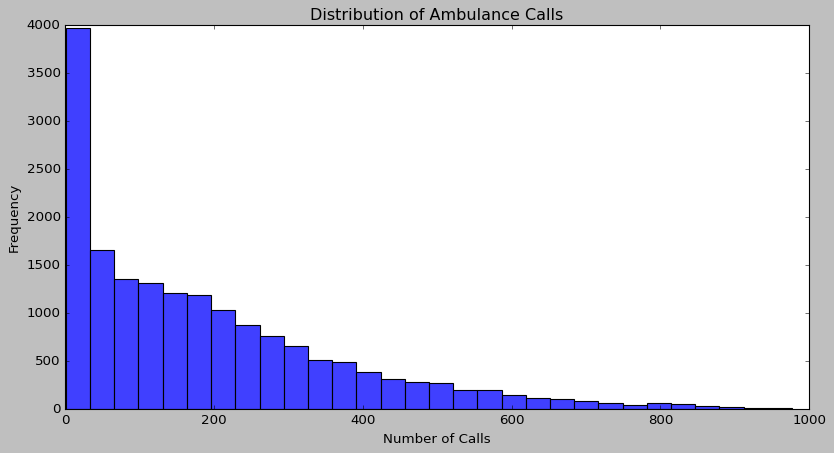

In [18]:
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(12, 6))
sns.histplot(df['cnt'], bins=30)
plt.title('Distribution of Ambulance Calls')
plt.xlabel('Number of Calls')
plt.ylabel('Frequency')
plt.show()

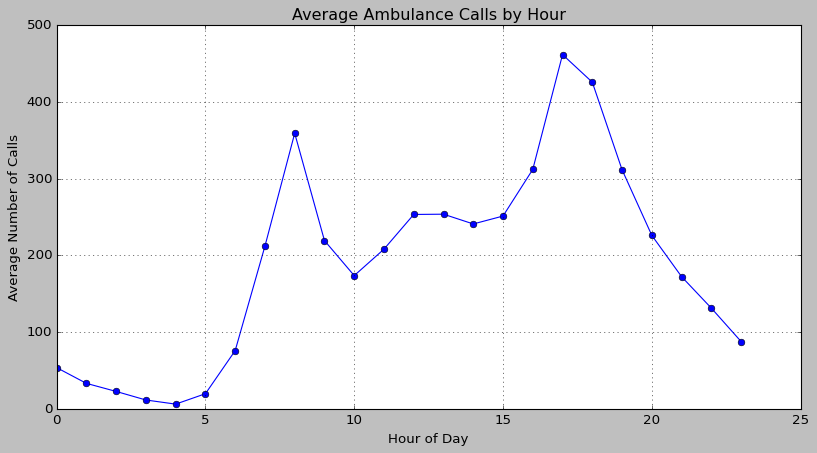

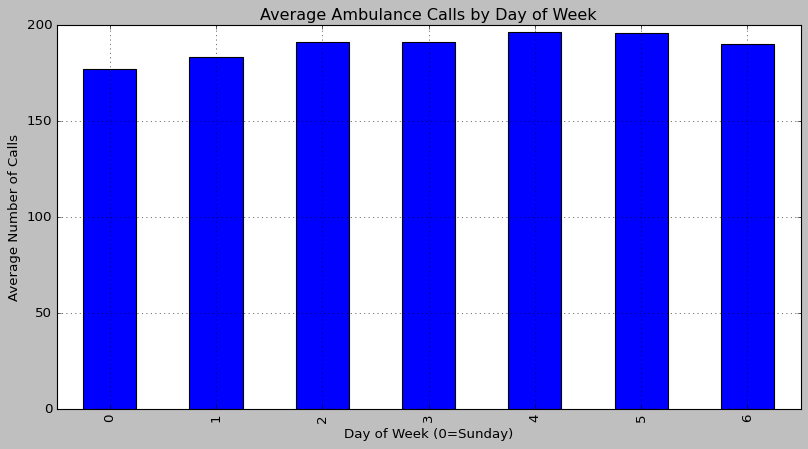

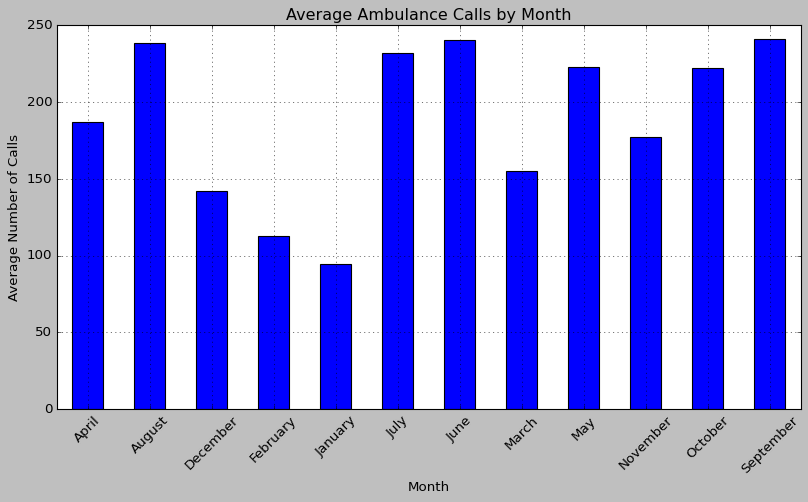

In [19]:
hourly_avg = df.groupby('hr')['cnt'].mean()
plt.figure(figsize=(12, 6))
hourly_avg.plot(kind='line', marker='o')
plt.title('Average Ambulance Calls by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Number of Calls')
plt.grid(True)
plt.show()

weekly_avg = df.groupby('weekday')['cnt'].mean()
plt.figure(figsize=(12, 6))
weekly_avg.plot(kind='bar')
plt.title('Average Ambulance Calls by Day of Week')
plt.xlabel('Day of Week (0=Sunday)')
plt.ylabel('Average Number of Calls')
plt.grid(True)
plt.show()

monthly_avg = df.groupby('month_name')['cnt'].mean()
plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='bar')
plt.title('Average Ambulance Calls by Month')
plt.xlabel('Month')
plt.ylabel('Average Number of Calls')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

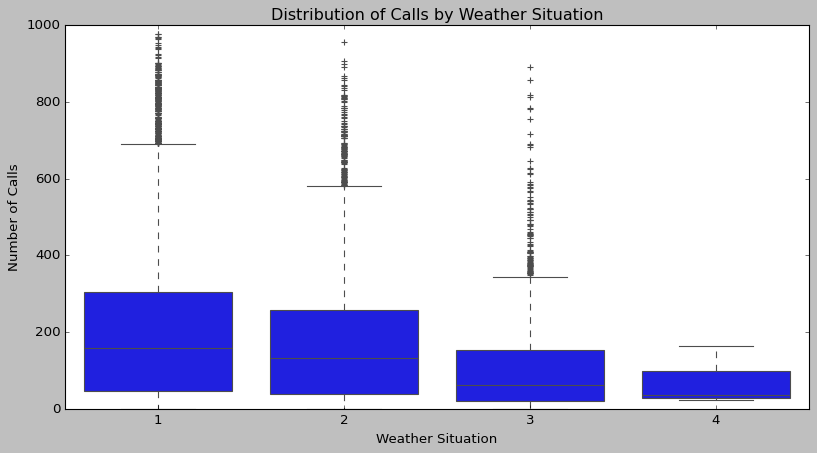

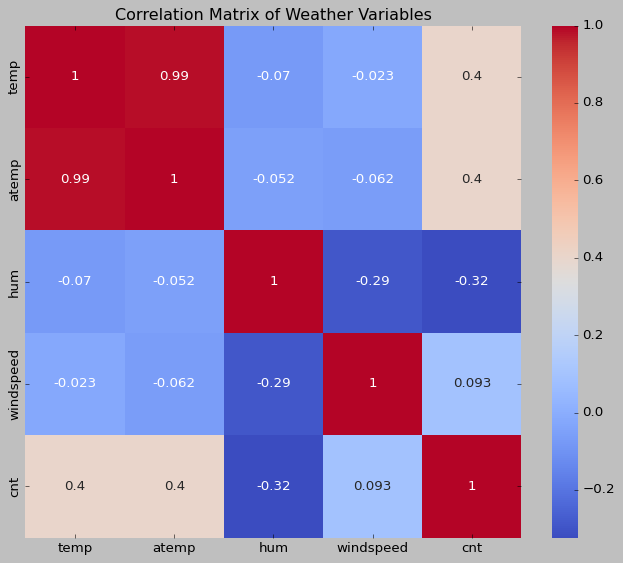

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title('Distribution of Calls by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Number of Calls')
plt.show()

weather_vars = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
correlation = df[weather_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Weather Variables')
plt.show()

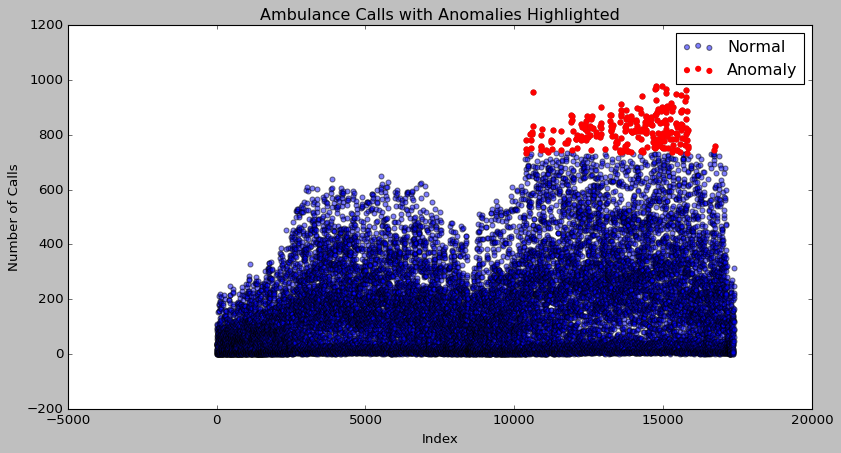


Number of anomalies detected: 244

Anomalies Summary:
            date  cnt  weathersit  temp  hour_band
10383 2012-03-13  734           1  0.70  Afternoon
10406 2012-03-14  782           1  0.70  Afternoon
10407 2012-03-14  749           1  0.70  Afternoon
10431 2012-03-15  746           1  0.66  Afternoon
10527 2012-03-19  801           1  0.64  Afternoon


In [21]:
z_scores = stats.zscore(df['cnt'])

anomalies = df[abs(z_scores) > 3].copy()

plt.figure(figsize=(12, 6))
plt.scatter(df.index, df['cnt'], alpha=0.5, label='Normal')
plt.scatter(anomalies.index, anomalies['cnt'], color='red', label='Anomaly')
plt.title('Ambulance Calls with Anomalies Highlighted')
plt.xlabel('Index')
plt.ylabel('Number of Calls')
plt.legend()
plt.show()

print("\nNumber of anomalies detected:", len(anomalies))
print("\nAnomalies Summary:")
print(anomalies[['date', 'cnt', 'weathersit', 'temp', 'hour_band']].head())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000312 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 281
[LightGBM] [Info] Number of data points in the train set: 13903, number of used features: 12
[LightGBM] [Info] Start training from score 190.577070

Model Performance:
RMSE: 40.40
R² Score: 0.95


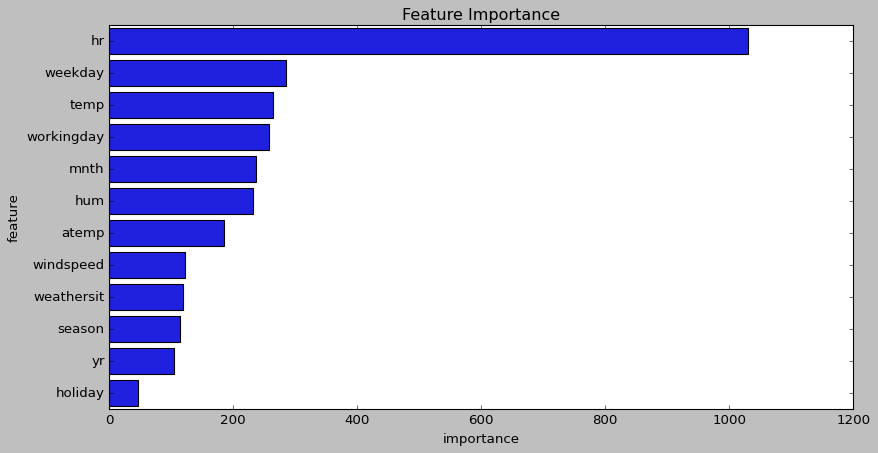


Top 5 Most Important Features:
      feature  importance
3          hr        1030
5     weekday         285
8        temp         265
6  workingday         258
2        mnth         237

Summary Statistics by Season:
         count        mean         std  min   25%    50%    75%    max
season                                                                
0       4496.0  236.016237  197.711630  1.0  68.0  199.0  345.0  977.0
1       4242.0  111.114569  119.224010  1.0  23.0   76.0  158.0  801.0
2       4409.0  208.344069  188.362473  1.0  46.0  165.0  311.0  957.0
3       4232.0  198.868856  182.967972  1.0  46.0  155.5  295.0  967.0

Average Calls by Weather Situation:
weathersit
1    204.87
2    175.17
3    111.58
4     74.33
Name: cnt, dtype: float64

Peak Hours (Top 5):
hr
17    461.452055
18    425.510989
8     359.011004
16    311.983562
19    311.523352
Name: cnt, dtype: float64


In [22]:
categorical_columns = ['season', 'weathersit', 'holiday', 'weekday', 'workingday']
for col in categorical_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
            'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

X = df[features]
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=importance)
plt.title('Feature Importance')
plt.show()

print("\nTop 5 Most Important Features:")
print(importance.head())

print("\nSummary Statistics by Season:")
print(df.groupby('season')['cnt'].describe())

print("\nAverage Calls by Weather Situation:")
print(df.groupby('weathersit')['cnt'].mean().round(2))

print("\nPeak Hours (Top 5):")
print(hourly_avg.sort_values(ascending=False).head())
